# Stalling Law Fit

This notebook estimates an empirical relation between the CDM spike mass and the late-time SMBH separation.

The expensive N-body mass sweep is not repeated here. Instead, this notebook loads the separation histories saved by `parameter_sweep_spike_mass.ipynb` and uses the final point of each curve as the stalling distance.


# Imports and Global Parameters

Define the binary mass scale, reconstruct the same spike-mass grid used in the mass sweep, and point to the saved NumPy data file.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

from cdm_spike_utils import apply_publication_style, plot_parameter_sweep

# Same primary SMBH mass and sweep resolution used in parameter_sweep_spike_mass.ipynb.
M_1 = 3e9
N_particles = 80
N_masses = 100
N_years = 20000
N_frames = 600

t_array = np.linspace(0, N_years, N_frames)
M_spike = np.linspace(0.01, 1.6, N_masses) * M_1
M_frac = M_spike / M_1

data_file = f'distance_vs_time_sweep_spike_mass_N={N_particles}_Nsweep={N_masses}_softened.npz' 


# Load Mass Sweep Data

Load the saved SMBH separation histories from the spike-mass sweep. The array has one row per spike mass and one column per saved time step.


In [2]:
data = np.load(data_file)
avg_distance_tot = data['avg_distance_tot']

if avg_distance_tot.shape != (N_masses, N_frames):
    raise ValueError(
        f'Expected data shape {(N_masses, N_frames)}, but found {avg_distance_tot.shape}. '
        'Check that N_masses, N_frames, and data_file match the saved mass sweep.'
    )

final_distance = avg_distance_tot[:, -1]
print(f'Loaded {data_file}')
print(f'Data shape: {avg_distance_tot.shape}')


Loaded distance_vs_time_sweep_spike_mass_N=80_Nsweep=100_softened.npz
Data shape: (100, 600)


# Plot Loaded Separation Curves

Each curve shows the saved separation history for one spike mass. The final point of each curve is the stalling distance used in the empirical fit.


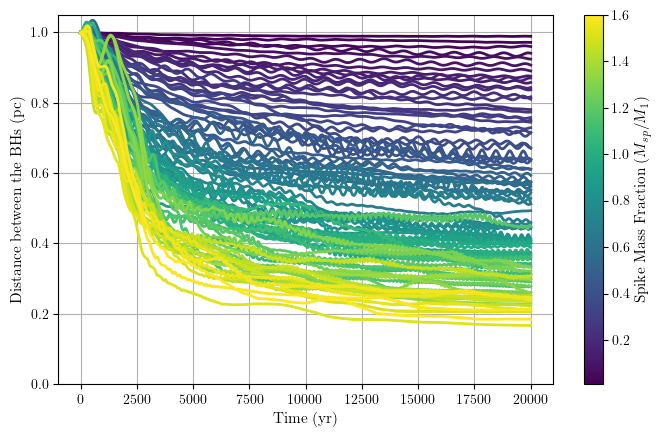

In [3]:
apply_publication_style(use_tex=True)

fig1, ax1d = plot_parameter_sweep(
    t_array=t_array,
    distance_histories=avg_distance_tot,
    parameter_values=M_frac,
    colorbar_label='Spike Mass Fraction ($M_{sp} / M_1$)',
    cmap_name='viridis',
    output_path=f'Distance_vs_time_loaded_Mspike_N={N_particles}_Nscanning={N_masses}_softened.pdf',
)

plt.show()


# Fit the Stalling Distance

Fit a simple exponential relation between spike mass fraction and the final SMBH separation. This is a phenomenological fit to the saved N-body data.


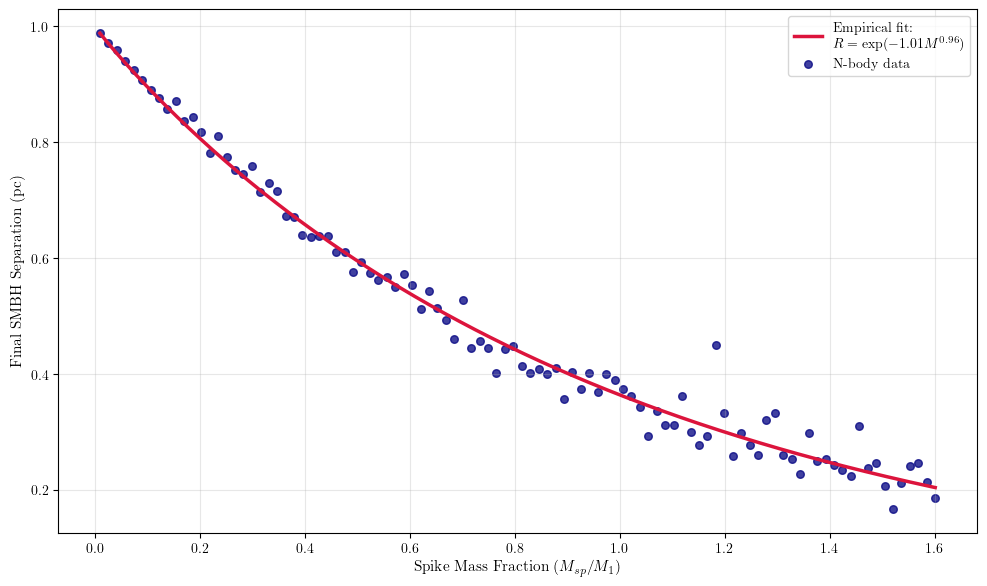

C = 1.0124
alpha = 0.9634


In [4]:
def exp_fit(M, C, alpha):
    return np.exp(-C * (M ** alpha))

popt, pcov = curve_fit(exp_fit, M_frac, final_distance, p0=[2.0, 1.0])
C_fit, alpha_fit = popt

M_fit_smooth = np.linspace(min(M_frac), max(M_frac), 500)
fit_line = exp_fit(M_fit_smooth, C_fit, alpha_fit)

plt.figure(figsize=(10, 6), facecolor='white')
label_str = f'Empirical fit:\n$R = \\exp(-{C_fit:.2f} M^{{{alpha_fit:.2f}}})$'
plt.plot(M_fit_smooth, fit_line, color='crimson', linewidth=2.5, label=label_str)
plt.scatter(M_frac, final_distance, color='navy', label='N-body data', s=30, alpha=0.75)

plt.xlabel('Spike Mass Fraction ($M_{sp} / M_1$)')
plt.ylabel('Final SMBH Separation (pc)')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('stalling_law_fit_from_mass_sweep.pdf')
plt.show()

print(f'C = {C_fit:.4f}')
print(f'alpha = {alpha_fit:.4f}')
